In [ ]:
import zipfile
import os
import unicodedata

import re

import spacy
nlp = spacy.load("en_core_web_sm")

import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
zip_path = "/content/Corpus.zip"
extract_path = "data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
  zip_ref.extractall(extract_path)

print("Unzipped to: ", extract_path)

Unzipped to:  data


In [ ]:
def load_texts(folder_path):
  texts = []
  filenames = []

  for file in os.listdir(folder_path):
    if file.endswith(".txt"):
      path = os.path.join(folder_path, file)
      with open(path, "r", encoding = "utf-8") as f:
        texts.append(f.read())
        filenames.append(file)

  return texts, filenames

In [ ]:
# Step 1: Load the texts (already manually cleaned)
print("Loading texts...")

romantic_texts, romantic_filenames = load_texts("data/english_romantic")
gothic_texts, gothic_filenames = load_texts("data/english_gothic")

print("\nNumber of English Romantic texts: ", len(romantic_texts))
print("Number of English Gothic texts: ", len(gothic_texts))

Loading texts...

Number of English Romantic texts:  6
Number of English Gothic texts:  6


In [ ]:
def preprocess(text):
  """
  Preprocessing that preserves stylistic signals.
  """

  # Archaic characters
  text = re.sub(r'ſ', 's', text)
  text = re.sub(r'æ', 'ae', text)
  text = re.sub(r'œ', 'oe', text)
  text = re.sub(r'ﬁ', 'fi', text)
  text = re.sub(r'ﬂ', 'fl', text)

  # Unicode diacritics
  text = "".join(c for c in unicodedata.normalize("NFD", text) if unicodedata.category(c) != "Mn")

  # Keep only letters and some punctuation ("'.!?:;)
  text = re.sub(r"[^a-zA-Z0-9.,!?;:()\"'\-\s]", "", text)

  # Normalize whitespace
  text = re.sub(r"\s+", " ", text).strip()

  return text

def save_cleaned_texts(texts, filenames, output_folder):
  os.makedirs(output_folder, exist_ok = True)

  for text, filename in zip(texts, filenames):
    out_path = os.path.join(output_folder, filename)
    with open(out_path, "w", encoding = "utf-8") as f:
      f.write(text)

In [ ]:
# Step 2: Preprocess the texts
print("Preprocessing texts...")

romantic_texts = [preprocess(t) for t in romantic_texts]
gothic_texts = [preprocess(t) for t in gothic_texts]

save_cleaned_texts(romantic_texts, romantic_filenames, "./cleaned_romantic")
save_cleaned_texts(gothic_texts, gothic_filenames, "./cleaned_gothic")

print("\n Successfully cleaned and saved files! ")

Preprocessing texts...

 Successfully cleaned and saved files! 


In [ ]:
sia = SentimentIntensityAnalyzer()

In [ ]:
def split_into_chunks(text, chunk_size = 1000):
  words = text.split()
  return [" ".join(words[i:i + chunk_size]) for i in range(0, len(words), chunk_size)]

def sentiment_scores(chunks):
  scores = []
  for chunk in chunks:
    score = sia.polarity_scores(chunk)["compound"]
    scores.append(score)

  return scores

def build_trajectory(text, chunk_size = 1000):
  chunks = split_into_chunks(text, chunk_size)
  scores = sentiment_scores(chunks)

  x = np.linspace(0, 1, len(scores))

  return x, scores

def plot_trajectory(x, scores, title = "Sentiment Trajectory"):
  plt.figure(figsize = (10, 4))
  plt.plot(x, scores, marker = "o", linewidth = 1)
  plt.axhline(0, linestyle = "--")
  plt.title(title)
  plt.xlabel("Narrative Progress")
  plt.ylabel("Sentiment")
  plt.show()

def average_trajectory(texts, chunk_size = 1000, n_points = 50):
  interpolated = []

  for text in texts:
    x, scores = build_trajectory(text, chunk_size)

    new_x = np.linspace(0, 1, n_points)
    new_scores = np.interp(new_x, x, scores)

    interpolated.append(new_scores)

  return new_x, np.mean(interpolated, axis = 0)

Plotting sample trajectories...


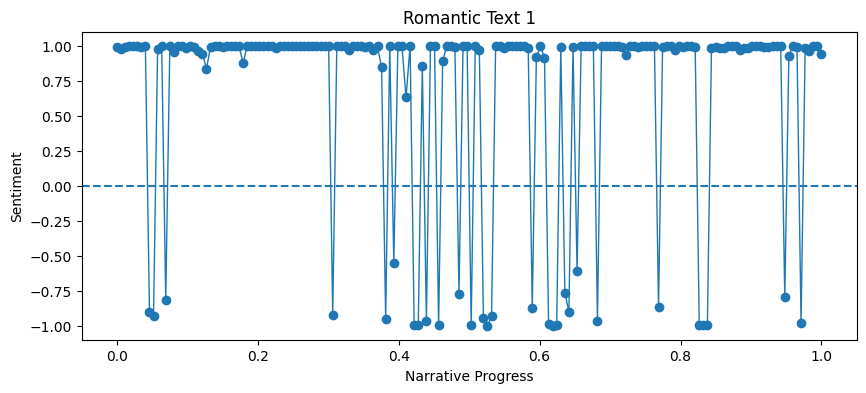

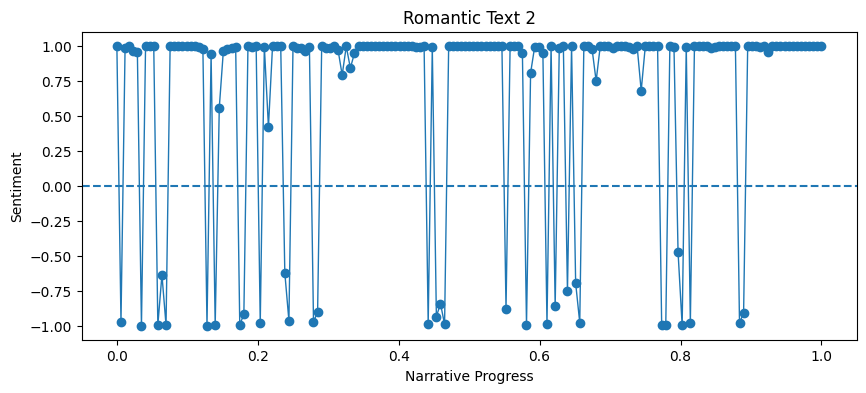

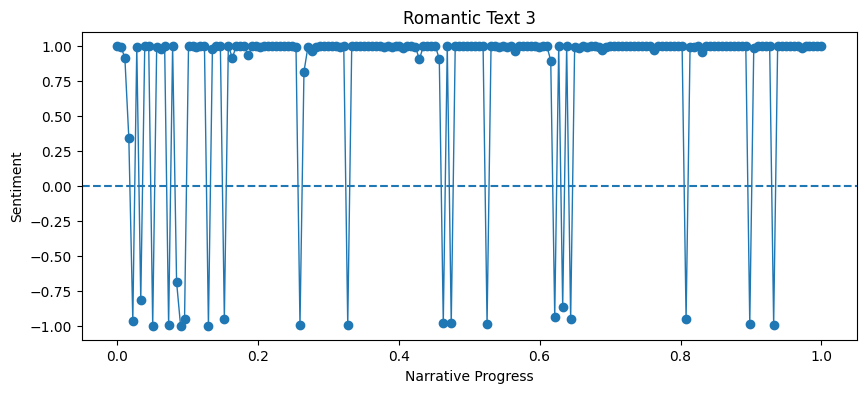

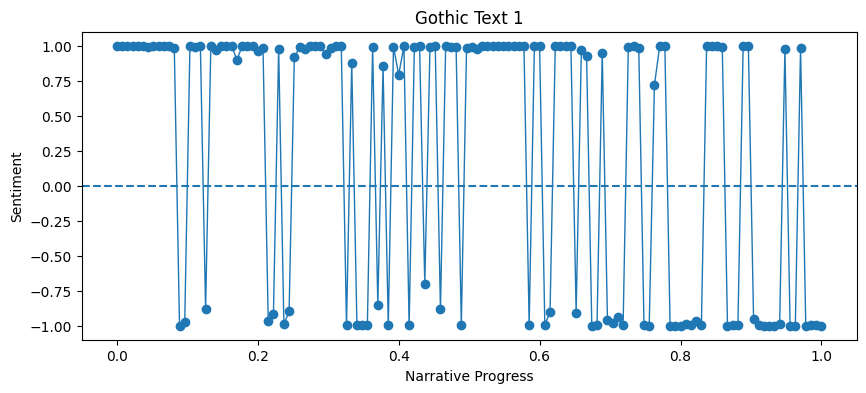

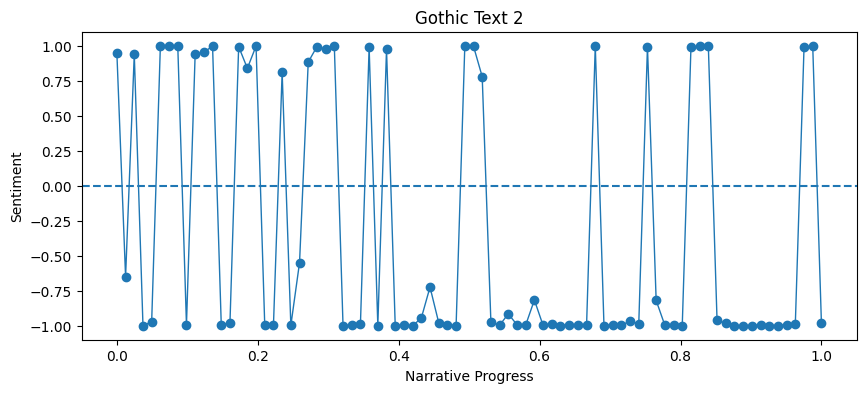

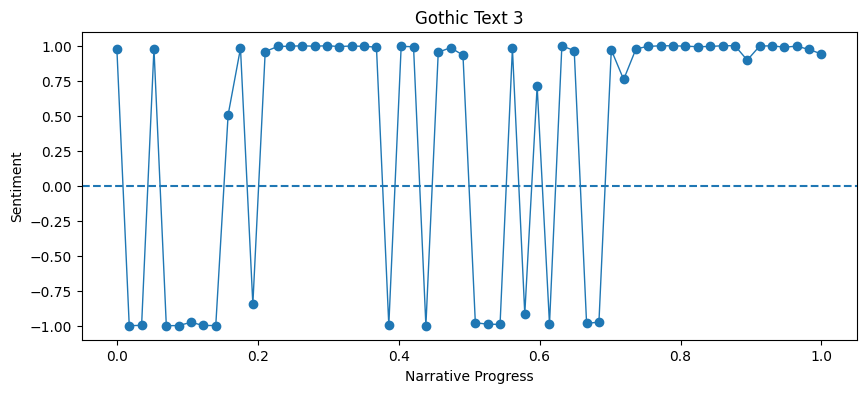

In [ ]:
# Step 3: Plot sentiment trajectories
print("Plotting sample trajectories...")

# Romantic samples
for i, text in enumerate(romantic_texts[:3]):
  x, scores = build_trajectory(text)
  plot_trajectory(x, scores, title = f"Romantic Text {i + 1}")

# Gothic samples
for i, text in enumerate(gothic_texts[:3]):
  x, scores = build_trajectory(text)
  plot_trajectory(x, scores, title = f"Gothic Text {i + 1}")

Computing average trajectories...


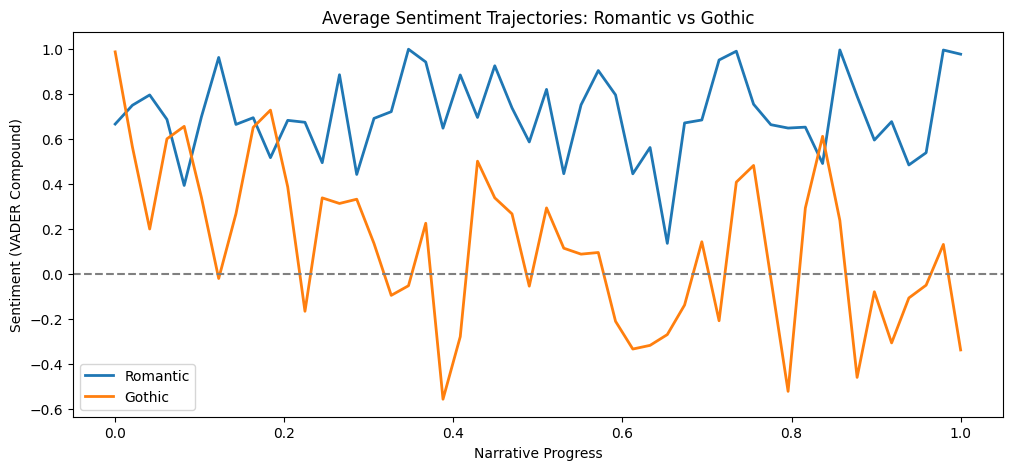

In [ ]:
print("Computing average trajectories...")

x_r, avg_r = average_trajectory(romantic_texts)
x_g, avg_g = average_trajectory(gothic_texts)

plt.figure(figsize = (12, 5))

plt.plot(x_r, avg_r, label = "Romantic", linewidth = 2)
plt.plot(x_g, avg_g, label = "Gothic", linewidth = 2)

plt.axhline(0, linestyle = "--", color = "gray")

plt.title("Average Sentiment Trajectories: Romantic vs Gothic")
plt.xlabel("Narrative Progress")
plt.ylabel("Sentiment (VADER Compound)")
plt.legend()

plt.show()